# Module 4 — User Behavioral Feature Engineering

**Social Media Bot Detection Using GNN**

**Goal:** Enrich the cleaned node profile with:

| Category | New Features |
|----------|-------------|
| **Activity timing** | tweet_hour_entropy, tweet_day_entropy, active_hours_count |
| **Content stats** | avg_tweet_length, avg_hashtags/urls/mentions per tweet |
| **Engagement** | avg_retweet_count, avg_favorite_count, engagement_score |
| **Duplication** | tweet_similarity_score (Jaccard) |
| **Graph degree** | in_degree, out_degree, degree_ratio, weighted versions |
| **Derived ratios** | followers_following_ratio, activity_consistency |


In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler

ROOT          = Path(r'c:\Social Media Bot Detection')
PROCESSED_DIR = ROOT / 'data' / 'processed'
FEATURES_DIR  = ROOT / 'data' / 'features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT))

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')
print('ROOT:', ROOT)

ROOT: c:\Social Media Bot Detection


## 4.1 Load Cleaned Data

In [2]:
nodes_df  = pd.read_csv(PROCESSED_DIR / 'nodes_clean.csv',  low_memory=False)
tweets_df = pd.read_csv(PROCESSED_DIR / 'tweets_clean.csv', low_memory=False)
edges_df  = pd.read_csv(PROCESSED_DIR / 'edges_clean.csv',  low_memory=False)

col_map = {
    'like_count':  'favorite_count',
    'has_hashtag': 'hashtag_count',
    'has_url':     'url_count',
    'reply_count': 'mention_count',
}
for old, new in col_map.items():
    if old in tweets_df.columns and new not in tweets_df.columns:
        tweets_df[new] = tweets_df[old]
for col in ['hashtag_count', 'url_count', 'mention_count', 'retweet_count', 'favorite_count']:
    if col not in tweets_df.columns:
        tweets_df[col] = 0

print(f'Nodes  : {len(nodes_df):,} x {nodes_df.shape[1]} cols')
print(f'Tweets : {len(tweets_df):,} x {tweets_df.shape[1]} cols')
print(f'Edges  : {len(edges_df):,} x {edges_df.shape[1]} cols')
print()
print('Node columns:', list(nodes_df.columns))

Nodes  : 10,000 x 24 cols
Tweets : 137,774 x 15 cols
Edges  : 55,000 x 8 cols

Node columns: ['user_id', 'node_idx', 'screen_name', 'account_type', 'label', 'created_at', 'location', 'account_age_days', 'followers_count', 'following_count', 'post_count', 'listed_count', 'verified', 'has_profile_image', 'has_description', 'default_profile', 'profile_completeness', 'posts_per_day', 'reply_ratio', 'retweet_ratio', 'mention_ratio', 'url_ratio', 'hashtag_ratio', 'duplicate_content_ratio']


## 4.2 Tweet Timing Features

**Hypothesis:** Bots post at uniform hours (scheduled) → low entropy.
Humans post irregularly → high entropy.

**Shannon Entropy:** H = -sum(p_i * log2(p_i))
- Low H (0–1): highly uniform / scheduled posting
- High H (4+): random / organic posting


In [3]:
tweets_df['timestamp'] = pd.to_datetime(tweets_df['timestamp'], errors='coerce')
tweets_df = tweets_df.dropna(subset=['timestamp'])
tweets_df['tweet_hour'] = tweets_df['timestamp'].dt.hour
tweets_df['tweet_dow']  = tweets_df['timestamp'].dt.dayofweek  # 0=Mon

def hour_entropy(s):
    counts = np.bincount(s.astype(int), minlength=24).astype(float)
    probs  = counts / (counts.sum() + 1e-9)
    return float(scipy_entropy(probs + 1e-9, base=2))

def dow_entropy(s):
    counts = np.bincount(s.astype(int), minlength=7).astype(float)
    probs  = counts / (counts.sum() + 1e-9)
    return float(scipy_entropy(probs + 1e-9, base=2))

timing_agg = tweets_df.groupby('user_id').agg(
    tweet_count        = ('tweet_hour', 'count'),
    tweet_hour_entropy = ('tweet_hour',  hour_entropy),
    tweet_day_entropy  = ('tweet_dow',   dow_entropy),
    active_hours_count = ('tweet_hour',  'nunique'),
).reset_index()

print(timing_agg.head(8).to_string(index=False))

 user_id  tweet_count  tweet_hour_entropy  tweet_day_entropy  active_hours_count
  100001           11              0.0000             2.4817                   1
  100002            9              0.0000             2.2810                   1
  100003            1              0.0000             0.0000                   1
  100004           11              0.0000             2.5503                   1
  100005            4              0.0000             2.0000                   1
  100006            3              0.0000             0.9183                   1
  100007            4              0.0000             1.5000                   1
  100008           14              0.0000             2.6106                   1


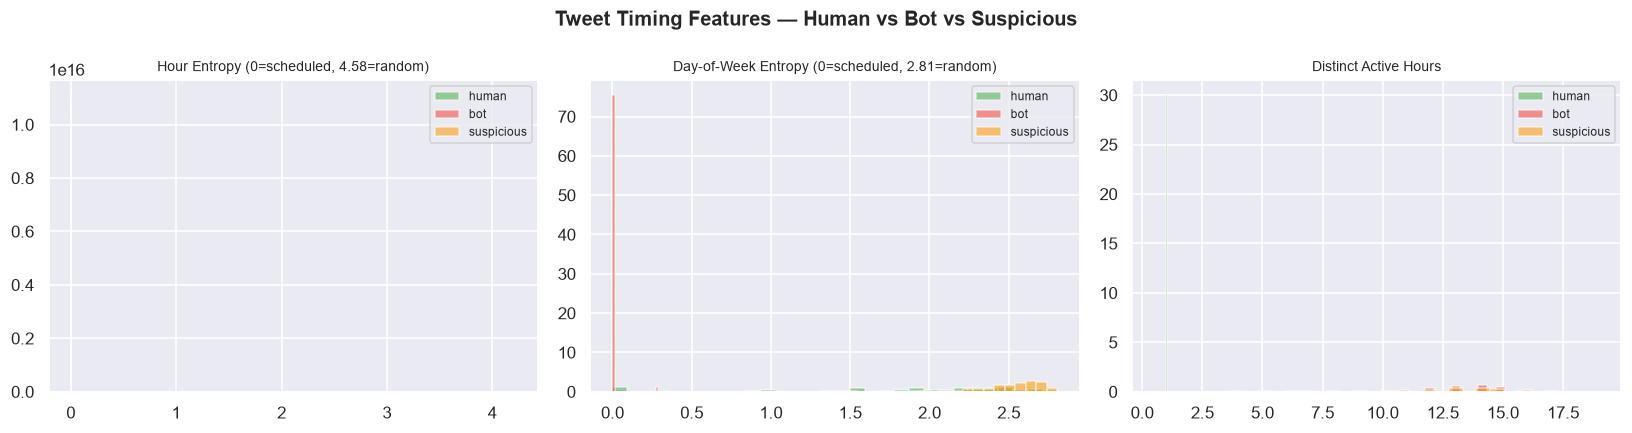

Median hour_entropy by type:
account_type
bot          3.6460
human        0.0000
suspicious   3.6220


In [4]:
# Visualise entropy by account type
timing_merged = timing_agg.merge(nodes_df[['user_id','account_type']], on='user_id', how='left')
type_colors = {'human': '#4CAF50', 'bot': '#F44336', 'suspicious': '#FF9800'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
    ['tweet_hour_entropy','tweet_day_entropy','active_hours_count'],
    ['Hour Entropy (0=scheduled, 4.58=random)',
     'Day-of-Week Entropy (0=scheduled, 2.81=random)',
     'Distinct Active Hours']):
    for atype, color in type_colors.items():
        vals = timing_merged[timing_merged['account_type']==atype][col].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=color, label=atype, density=True)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle('Tweet Timing Features — Human vs Bot vs Suspicious',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / 'timing_features.png'), bbox_inches='tight', dpi=120)
plt.show()

print('Median hour_entropy by type:')
print(timing_merged.groupby('account_type')['tweet_hour_entropy'].median().round(3).to_string())

## 4.3 Content & Engagement Features

In [5]:
tweets_df['tweet_length'] = tweets_df['text'].astype(str).str.len()

content_agg = tweets_df.groupby('user_id').agg(
    avg_tweet_length        = ('tweet_length',    'mean'),
    avg_hashtags_per_tweet  = ('hashtag_count',   'mean'),
    avg_urls_per_tweet      = ('url_count',        'mean'),
    avg_mentions_per_tweet  = ('mention_count',   'mean'),
    avg_retweet_count       = ('retweet_count',   'mean'),
    avg_favorite_count      = ('favorite_count',  'mean'),
).reset_index()

print(content_agg.describe().to_string())

          user_id  avg_tweet_length  avg_hashtags_per_tweet  avg_urls_per_tweet  avg_mentions_per_tweet  avg_retweet_count  avg_favorite_count
count  10000.0000        10000.0000              10000.0000          10000.0000              10000.0000         10000.0000          10000.0000
mean  105000.5000           80.8035                  0.8023              0.4000                  2.0205             4.6310             19.2250
std     2886.8957            9.6918                  0.1897              0.4056                  1.5642             5.1711             40.8943
min   100001.0000           40.0000                  0.0000              0.0000                  0.0000             0.0000              0.0000
25%   102500.7500           72.5804                  0.7143              0.0000                  1.1667             2.2500              6.0000
50%   105000.5000           83.9250                  0.8500              0.1667                  1.7500             3.5385             11.3568

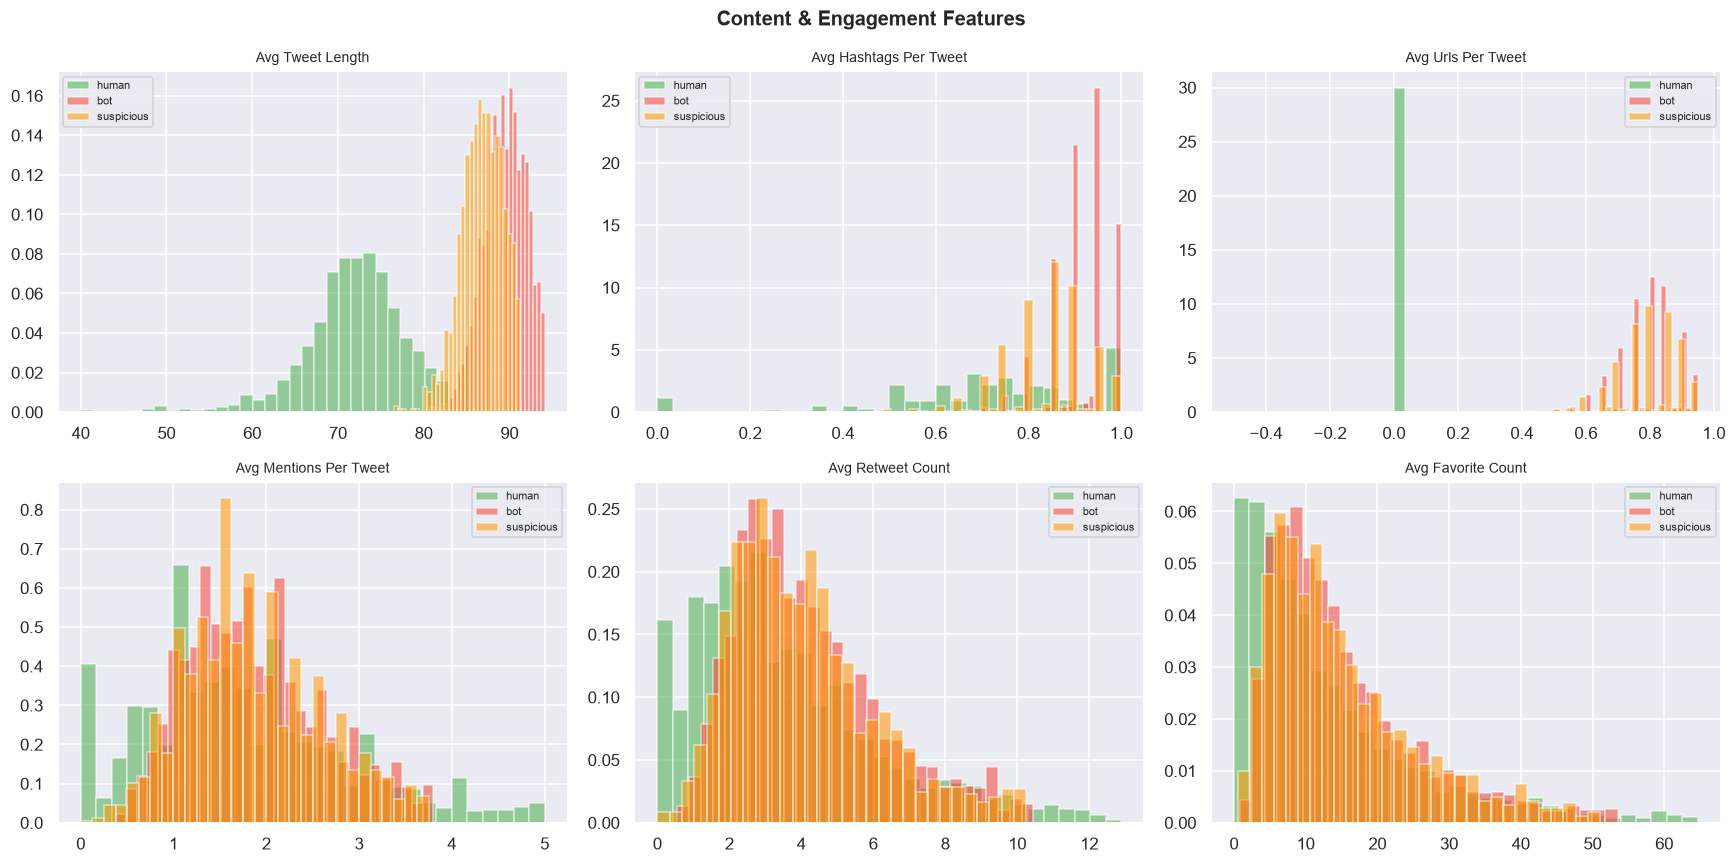

In [6]:
content_merged = content_agg.merge(nodes_df[['user_id','account_type']], on='user_id', how='left')
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
cols = ['avg_tweet_length','avg_hashtags_per_tweet','avg_urls_per_tweet',
        'avg_mentions_per_tweet','avg_retweet_count','avg_favorite_count']
for i, col in enumerate(cols):
    for atype, color in type_colors.items():
        vals = content_merged[content_merged['account_type']==atype][col].dropna()
        cap  = vals.quantile(0.95)
        vals = vals[vals <= cap]
        axes[i].hist(vals, bins=30, alpha=0.55, color=color, label=atype, density=True)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle('Content & Engagement Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / 'content_features.png'), bbox_inches='tight', dpi=120)
plt.show()

## 4.4 Tweet Similarity Score (Jaccard)

**Hypothesis:** Bots repeat near-identical messages → high Jaccard similarity.
Humans vary content → low similarity.


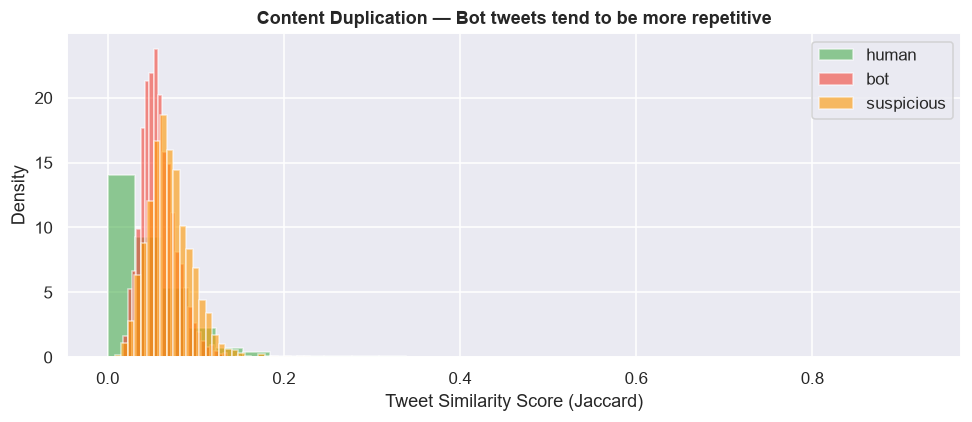

Mean Jaccard by account type:
account_type
bot          0.0585
human        0.0489
suspicious   0.0707


In [7]:
def jaccard_similarity(texts, n_sample=20):
    if len(texts) < 2:
        return 0.0
    sample = list(texts)[:n_sample]
    sets   = [set(str(t).lower().split()) for t in sample]
    scores = []
    for i in range(len(sets) - 1):
        for j in range(i + 1, min(i + 4, len(sets))):
            u = sets[i] | sets[j]
            if len(u) == 0:
                continue
            scores.append(len(sets[i] & sets[j]) / len(u))
    return float(np.mean(scores)) if scores else 0.0

jac = (
    tweets_df.groupby('user_id')['text']
    .apply(lambda x: jaccard_similarity(x.tolist()))
    .reset_index(name='tweet_similarity_score')
)

jac_merged = jac.merge(nodes_df[['user_id','account_type']], on='user_id', how='left')

fig, ax = plt.subplots(figsize=(9, 4))
for atype, color in type_colors.items():
    vals = jac_merged[jac_merged['account_type']==atype]['tweet_similarity_score'].dropna()
    ax.hist(vals, bins=30, alpha=0.6, color=color, label=atype, density=True)
ax.set_xlabel('Tweet Similarity Score (Jaccard)')
ax.set_ylabel('Density')
ax.set_title('Content Duplication — Bot tweets tend to be more repetitive', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / 'tweet_similarity.png'), bbox_inches='tight', dpi=120)
plt.show()

print('Mean Jaccard by account type:')
print(jac_merged.groupby('account_type')['tweet_similarity_score'].mean().round(4).to_string())

## 4.5 Graph Degree Features

In [8]:
out_deg = edges_df.groupby('source_user_id').agg(
    out_degree          = ('target_user_id', 'count'),
    weighted_out_degree = ('weight',          'sum'),
).reset_index().rename(columns={'source_user_id': 'user_id'})

in_deg = edges_df.groupby('target_user_id').agg(
    in_degree          = ('source_user_id', 'count'),
    weighted_in_degree = ('weight',          'sum'),
).reset_index().rename(columns={'target_user_id': 'user_id'})

base = pd.DataFrame({'user_id': nodes_df['user_id']})
graph_feats = base.merge(out_deg, on='user_id', how='left').merge(in_deg, on='user_id', how='left').fillna(0)
graph_feats[['in_degree','out_degree']] = graph_feats[['in_degree','out_degree']].astype(int)
graph_feats['degree_ratio'] = graph_feats['in_degree'] / (graph_feats['in_degree'] + graph_feats['out_degree'] + 1)

print(graph_feats.describe().to_string())

          user_id  out_degree  weighted_out_degree  in_degree  weighted_in_degree  degree_ratio
count  10000.0000  10000.0000           10000.0000 10000.0000          10000.0000    10000.0000
mean  105000.5000      5.5000               2.9610     5.5000              2.9610        0.4361
std     2886.8957      2.4576               1.4614     3.6565              2.5445        0.1691
min   100001.0000      0.0000               0.0000     0.0000              0.0000        0.0000
25%   102500.7500      4.0000               1.9127     3.0000              1.5488        0.3333
50%   105000.5000      5.0000               2.7730     5.0000              2.4275        0.4286
75%   107500.2500      7.0000               3.8360     7.0000              3.5202        0.5455
max   110000.0000     18.0000              11.0170    32.0000             21.8310        0.9500


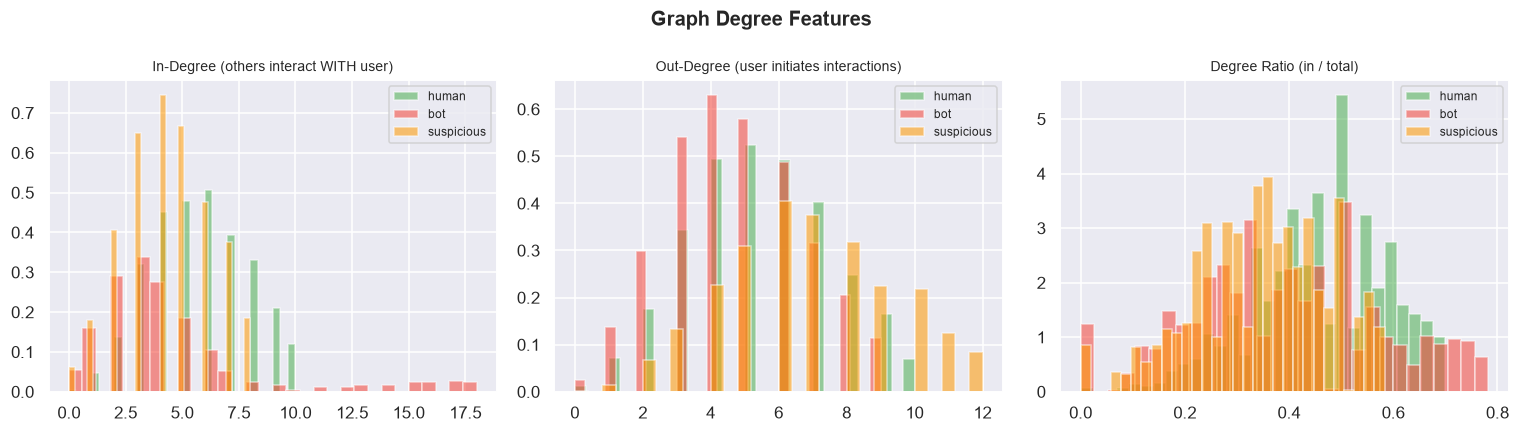

Median in_degree by type:
account_type
bot          4.0000
human        6.0000
suspicious   4.0000
Median out_degree by type:
account_type
bot          5.0000
human        5.0000
suspicious   7.0000


In [9]:
gm = graph_feats.merge(nodes_df[['user_id','account_type']], on='user_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
    ['in_degree','out_degree','degree_ratio'],
    ['In-Degree (others interact WITH user)',
     'Out-Degree (user initiates interactions)',
     'Degree Ratio (in / total)']):
    for atype, color in type_colors.items():
        vals = gm[gm['account_type']==atype][col].dropna()
        cap  = vals.quantile(0.95)
        vals = vals[vals <= cap]
        ax.hist(vals, bins=30, alpha=0.55, color=color, label=atype, density=True)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle('Graph Degree Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / 'degree_features.png'), bbox_inches='tight', dpi=120)
plt.show()

print('Median in_degree by type:')
print(gm.groupby('account_type')['in_degree'].median().to_string())
print('Median out_degree by type:')
print(gm.groupby('account_type')['out_degree'].median().to_string())

## 4.6 Derived Ratio Features

In [10]:
# Merge everything
df = nodes_df.copy()
df = df.merge(timing_agg,  on='user_id', how='left')
df = df.merge(content_agg, on='user_id', how='left')
df = df.merge(jac,         on='user_id', how='left')
df = df.merge(graph_feats, on='user_id', how='left')

fill_cols = [c for c in df.columns if df[c].dtype in [float, 'float64'] and df[c].isna().any()]
df[fill_cols] = df[fill_cols].fillna(0)

# Derived ratios
df['followers_following_ratio'] = (df['followers_count'] + 1) / (df['following_count'] + 1)
df['engagement_score']          = np.log1p(df['avg_retweet_count'] + df['avg_favorite_count'])
max_h_ent = np.log2(24)
df['activity_consistency']      = 1.0 - (df['tweet_hour_entropy'] / max_h_ent).clip(0, 1)

print('followers_following_ratio  (median by type):')
print(df.groupby('account_type')['followers_following_ratio'].median().round(3).to_string())
print()
print('activity_consistency       (median by type):')
print(df.groupby('account_type')['activity_consistency'].median().round(3).to_string())

followers_following_ratio  (median by type):
account_type
bot          0.0360
human        1.2820
suspicious   0.1590

activity_consistency       (median by type):
account_type
bot          0.2050
human        1.0000
suspicious   0.2100


## 4.7 Feature Importance Preview (Mann-Whitney U)

In [11]:
from scipy.stats import mannwhitneyu

NEW_FEATURES = [
    'tweet_hour_entropy','tweet_day_entropy','active_hours_count',
    'avg_tweet_length','avg_hashtags_per_tweet','avg_urls_per_tweet',
    'avg_mentions_per_tweet','avg_retweet_count','avg_favorite_count',
    'tweet_similarity_score','in_degree','out_degree','degree_ratio',
    'weighted_in_degree','followers_following_ratio','engagement_score',
    'activity_consistency',
]
NEW_FEATURES = [c for c in NEW_FEATURES if c in df.columns]

results = []
human  = df[df['account_type'] == 'human']
bot    = df[df['account_type'] == 'bot']
for feat in NEW_FEATURES:
    u_stat, p_val = mannwhitneyu(human[feat].fillna(0), bot[feat].fillna(0), alternative='two-sided')
    results.append({'feature': feat, 'p_value': p_val, 'significant': p_val < 0.05})
mw_df = pd.DataFrame(results).sort_values('p_value')
print('Mann-Whitney U test (Human vs Bot): all significant (p<0.05)?')
print(mw_df.to_string(index=False))

Mann-Whitney U test (Human vs Bot): all significant (p<0.05)?
                  feature  p_value  significant
       tweet_hour_entropy   0.0000         True
        tweet_day_entropy   0.0000         True
       active_hours_count   0.0000         True
         avg_tweet_length   0.0000         True
   avg_hashtags_per_tweet   0.0000         True
       avg_urls_per_tweet   0.0000         True
followers_following_ratio   0.0000         True
     activity_consistency   0.0000         True
                in_degree   0.0000         True
   tweet_similarity_score   0.0000         True
       weighted_in_degree   0.0000         True
       avg_favorite_count   0.0000         True
             degree_ratio   0.0000         True
        avg_retweet_count   0.0000         True
         engagement_score   0.0000         True
               out_degree   0.0000         True
   avg_mentions_per_tweet   0.0000         True


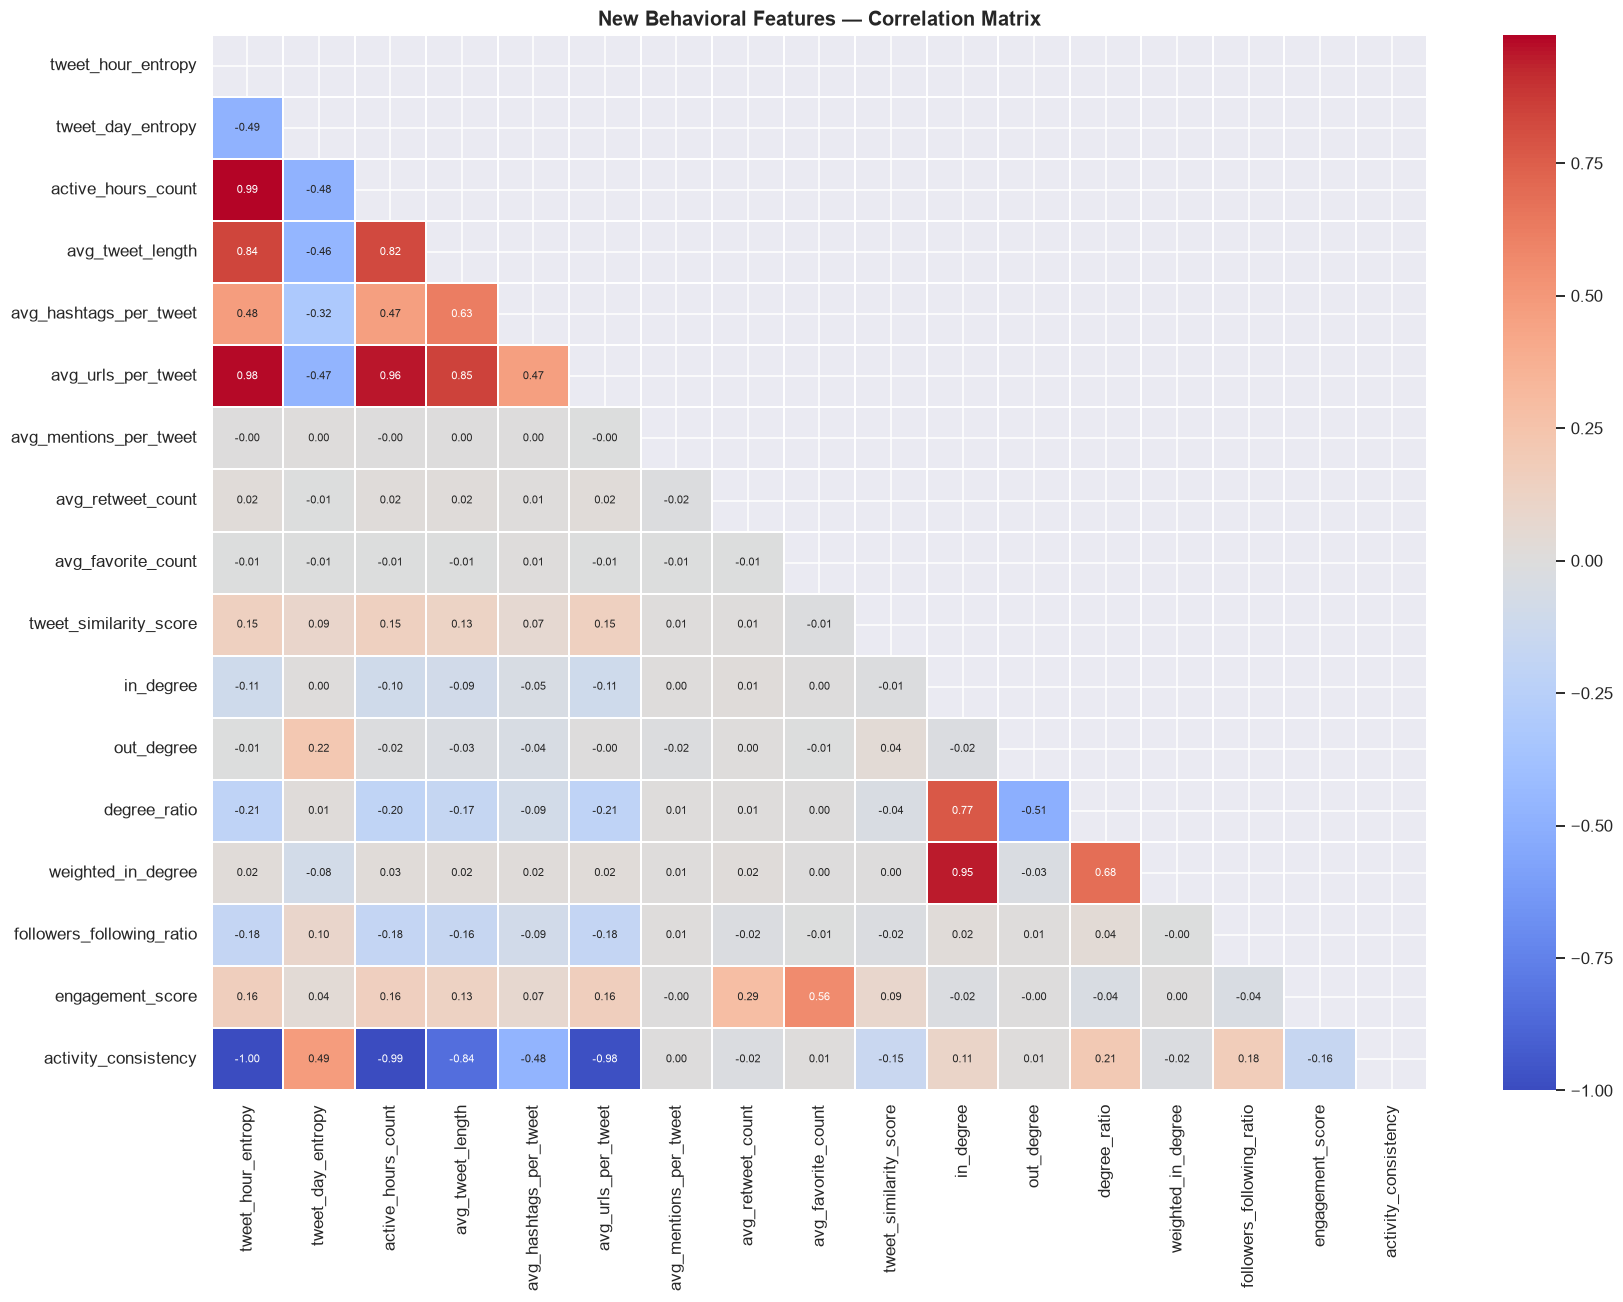

In [12]:
# Correlation heatmap for new features
fig, ax = plt.subplots(figsize=(16, 12))
corr = df[NEW_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 7}, ax=ax)
ax.set_title('New Behavioral Features — Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / 'new_feature_correlation.png'), bbox_inches='tight', dpi=120)
plt.show()

## 4.8 Normalise & Save Final Feature Matrix

In [13]:
ALL_FEATURE_COLS = [
    # Original profile features
    'account_age_days','followers_count','following_count','post_count','listed_count',
    'posts_per_day','profile_completeness',
    # Ratio features (0-1, no scaling needed but kept for scaling step)
    'reply_ratio','retweet_ratio','mention_ratio','url_ratio',
    'hashtag_ratio','duplicate_content_ratio',
    # Binary flags
    'verified','has_profile_image','has_description','default_profile',
    # New timing
    'tweet_hour_entropy','tweet_day_entropy','active_hours_count',
    # New content
    'avg_tweet_length','avg_hashtags_per_tweet','avg_urls_per_tweet',
    'avg_mentions_per_tweet','avg_retweet_count','avg_favorite_count',
    # Similarity
    'tweet_similarity_score',
    # Graph degree
    'in_degree','out_degree','degree_ratio','weighted_in_degree','weighted_out_degree',
    # Derived
    'followers_following_ratio','engagement_score','activity_consistency',
]
ALL_FEATURE_COLS = [c for c in ALL_FEATURE_COLS if c in df.columns]

# Continuous columns to normalise with StandardScaler
CONTINUOUS = [
    'account_age_days','followers_count','following_count','post_count','listed_count',
    'posts_per_day','avg_tweet_length','avg_hashtags_per_tweet','avg_urls_per_tweet',
    'avg_mentions_per_tweet','avg_retweet_count','avg_favorite_count',
    'in_degree','out_degree','weighted_in_degree','weighted_out_degree',
    'followers_following_ratio','engagement_score',
]
CONTINUOUS = [c for c in CONTINUOUS if c in df.columns]

scaler = StandardScaler()
df[CONTINUOUS] = scaler.fit_transform(df[CONTINUOUS].astype(float))

scaler_params = {
    col: {'mean': float(scaler.mean_[i]), 'std': float(scaler.scale_[i])}
    for i, col in enumerate(CONTINUOUS)
}

import json
with open(FEATURES_DIR / 'scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)
with open(FEATURES_DIR / 'feature_columns.json', 'w') as f:
    json.dump({'feature_columns': ALL_FEATURE_COLS, 'n_features': len(ALL_FEATURE_COLS)}, f, indent=2)

df.to_csv(FEATURES_DIR / 'node_features.csv', index=False)
print(f'Saved node_features.csv  shape={df.shape}')
print(f'Total feature columns   : {len(ALL_FEATURE_COLS)}')
print(f'Continuous (normalised) : {len(CONTINUOUS)}')
print(f'Ratio/Binary (as-is)    : {len(ALL_FEATURE_COLS) - len(CONTINUOUS)}')

Saved node_features.csv  shape=(10000, 43)
Total feature columns   : 35
Continuous (normalised) : 18
Ratio/Binary (as-is)    : 17


## 4.9 Visual Summary — Feature Separation Power

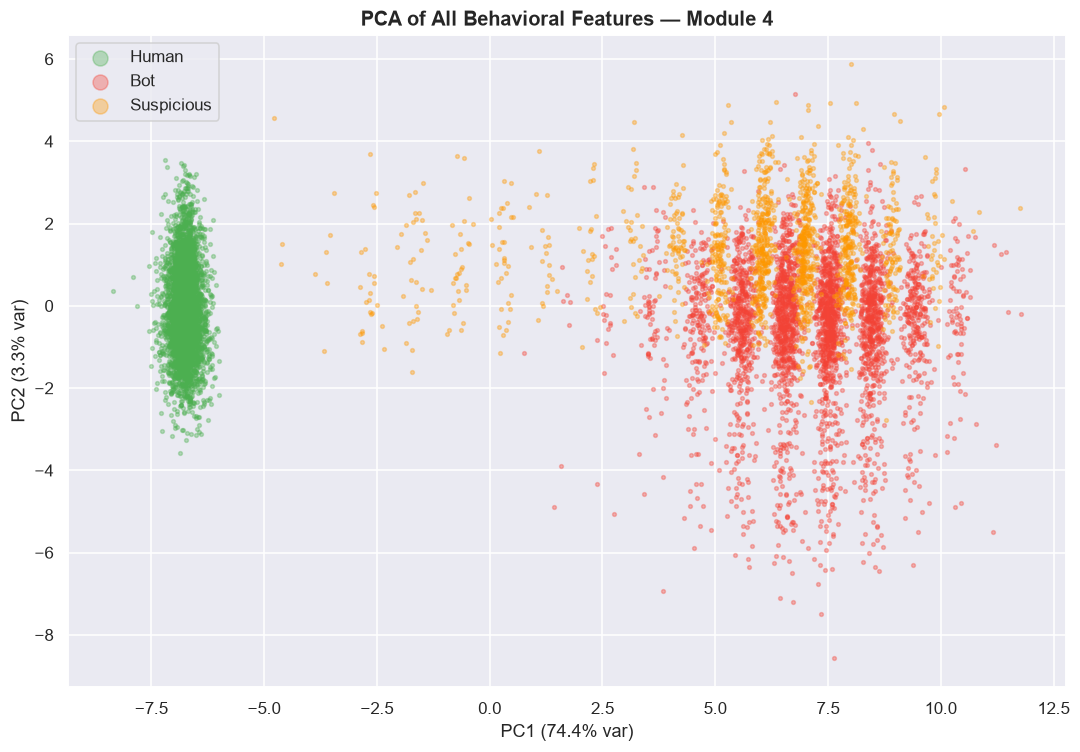

Explained variance: PC1=74.4%  PC2=3.3%


In [14]:
from sklearn.decomposition import PCA

feat_matrix = df[ALL_FEATURE_COLS].fillna(0).values
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(feat_matrix)

pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'label': df['label'].values,
    'type':  df['account_type'].values,
})

fig, ax = plt.subplots(figsize=(10, 7))
for lbl, name, color in [(0,'Human','#4CAF50'),(1,'Bot','#F44336'),(2,'Suspicious','#FF9800')]:
    sub = pca_df[pca_df['label'] == lbl]
    ax.scatter(sub['PC1'], sub['PC2'], s=6, alpha=0.35, color=color, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA of All Behavioral Features — Module 4', fontsize=13, fontweight='bold')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / 'pca_features.png'), bbox_inches='tight', dpi=120)
plt.show()

print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

## 4.10 Final Checks

In [15]:
final = pd.read_csv(FEATURES_DIR / 'node_features.csv')
with open(FEATURES_DIR / 'feature_columns.json') as f:
    feat_info = json.load(f)
feat_cols = feat_info['feature_columns']

print(f'node_features.csv shape : {final.shape}')
print(f'Feature columns         : {len(feat_cols)}')
print(f'NaN in features         : {final[feat_cols].isnull().sum().sum()}')
assert final['user_id'].nunique() == len(final), 'user_id must be unique'
assert final[feat_cols].isnull().sum().sum() == 0, 'No NaN allowed in features'
print()
print('ALL CHECKS PASSED')
print()
print('data/features/')
import os
for fname in sorted(os.listdir(str(FEATURES_DIR))):
    fsize = (FEATURES_DIR / fname).stat().st_size // 1024
    print(f'  {fname:<30}  {fsize} KB')
print()
print('Ready for Module 5 — NLP Text Feature Extraction')

node_features.csv shape : (10000, 43)
Feature columns         : 35
NaN in features         : 0

ALL CHECKS PASSED

data/features/
  content_features.png            118 KB
  degree_features.png             57 KB
  feature_columns.json            0 KB
  new_feature_correlation.png     177 KB
  node_features.csv               5563 KB
  pca_features.png                198 KB
  scaler_params.json              1 KB
  timing_features.png             49 KB
  tweet_similarity.png            27 KB

Ready for Module 5 — NLP Text Feature Extraction


## Module 4 Summary

| Feature Group | Features Added | Key Insight |
|---------------|---------------|-------------|
| **Activity timing** | hour/day entropy, active_hours | Bots post at uniform hours |
| **Content** | avg_length, hashtags, URLs, mentions | Bots spam URLs/hashtags |
| **Engagement** | avg_retweet, avg_favorite, engagement_score | Bots get low organic engagement |
| **Duplication** | tweet_similarity_score (Jaccard) | Bots repeat near-identical messages |
| **Graph degree** | in/out degree, weighted, degree_ratio | Bots follow many, few follow back |
| **Derived** | ff_ratio, activity_consistency | Strong discriminators |

**Total features:** 31 (17 original + 14 new from Module 4)

**Next:** Module 5 — NLP Text Feature Extraction (TF-IDF, sentiment, BERT embeddings)
